# 12 — Ablation: Full Fine-Tuning (Unfrozen Backbone)

**Goal:** test whether unfreezing the ResNet50 backbone lifts both the baseline and the augmented model. The original Phase 5 / Phase 10 results were obtained with `freeze_backbone=True` (head-only training, ~14k trainable params). That's a legitimate but weak baseline because it forces the model to classify skin lesions using ImageNet features that were never optimised for dermoscopy.

**What this notebook does:**

1. Re-runs the baseline (real-only) with the backbone fully trainable
2. Re-runs the augmented model (real + CVAE synthetic) with the backbone fully trainable
3. Compares per-class recall and macro-F1 against the frozen-backbone runs

**Key training change** — a two-LR optimiser:

- Backbone (pretrained, fragile): `lr = 1e-5`
- Head (random init, needs to move): `lr = 1e-4`

A single high LR on the backbone destroys the pretrained features in the first epoch and the model actually does worse than the frozen baseline — this is why the two-LR setup is non-negotiable for full fine-tuning.

**Naming convention.** All outputs use the `unfrozen` suffix so they do not overwrite the existing `baseline_resnet50_*` and `augmented_resnet50_*` artefacts. The report can then show both runs side by side.

**Reference course material:** the transfer-learning notes (full fine-tuning vs head-only) and the early-stopping example.

## 1. Imports, paths, seed

In [1]:
import sys
from pathlib import Path
import csv
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, recall_score, accuracy_score,
)

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES, get_class_weights        # noqa: E402
from src.dataset_augmented import AugmentedISICDataset                      # noqa: E402
from src.models.classifier import build_resnet50_classifier                 # noqa: E402

# Paths
SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
MANIFEST   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_manifest.csv'

RESULTS    = PROJECT_ROOT / 'results'
CKPT_DIR   = RESULTS / 'checkpoints'
LOGS_DIR   = RESULTS / 'logs'
PLOTS_DIR  = RESULTS / 'plots'
for d in (CKPT_DIR, LOGS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}'
assert IMAGES_DIR.exists(), f'images dir not found at {IMAGES_DIR}'
assert MANIFEST.exists(),   f'synthetic_manifest.csv not found at {MANIFEST}. Run Phase 8 first.'

# Seed everything
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Seed fixed to {SEED}')

Seed fixed to 42


## 2. Device check

Full fine-tuning on CPU is not realistic — a single epoch of ResNet50 with the backbone unfrozen on 7,009 images takes hours on CPU but ~1.5 minutes on a modern GPU. The notebook still runs on CPU but the loop should be terminated after one batch if no GPU is detected.

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected. Full fine-tuning is not feasible on CPU.')

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 85.1 GB


## 3. Hyperparameters

These mirror Phase 5 / Phase 10 with three intentional differences (the ablation variables):

| Setting              | Frozen runs (Phase 5/10) | Unfrozen runs (this notebook) |
|----------------------|--------------------------|-------------------------------|
| `freeze_backbone`    | `True`                   | `False`                        |
| Optimiser            | single LR `1e-4`         | two groups — backbone `1e-5`, head `1e-4` |
| Batch size           | 32                       | **16** (unfrozen ResNet50 ~ 2× memory)   |
| Epochs               | 25 / 40                  | **20** (full FT converges faster)        |

Everything else is identical: same splits, same augmentation pipeline, same class-weighted loss, same EarlyStopping logic, same `SOURCES_PER_CLASS`.

The `SOURCES_PER_CLASS` mapping is the one we settled on after Phase 9 (CVAE-only because CVAE beat cGAN on every class by FID).

In [3]:
IMG_SIZE      = 224
BATCH_SIZE    = 16        # smaller than frozen runs because unfrozen ResNet50 uses ~2x memory
EPOCHS        = 20
LR_BACKBONE   = 1e-5      # gentle — pretrained features should drift slowly
LR_HEAD       = 1e-4      # standard — randomly initialised, needs to move
WEIGHT_DECAY  = 1e-4
PATIENCE      = 5
NUM_WORKERS   = 2         # set to 0 if Mayar's environment hangs (Windows)
N_CLASSES     = len(CLASS_NAMES)

# Same per-class source mapping as Phase 10
SOURCES_PER_CLASS = {
    2: 'cvae',    # BCC
    3: 'cvae',    # AKIEC
    5: 'cvae',    # DF
    6: 'cvae',    # VASC
}

print(f'image size      : {IMG_SIZE}')
print(f'batch size      : {BATCH_SIZE}')
print(f'epochs          : {EPOCHS}')
print(f'lr (backbone)   : {LR_BACKBONE}')
print(f'lr (head)       : {LR_HEAD}')
print(f'patience        : {PATIENCE}')
print(f'sources per cls : {SOURCES_PER_CLASS}')

image size      : 224
batch size      : 16
epochs          : 20
lr (backbone)   : 1e-05
lr (head)       : 0.0001
patience        : 5
sources per cls : {2: 'cvae', 3: 'cvae', 5: 'cvae', 6: 'cvae'}


## 4. Transforms

Identical to Phase 5 / Phase 10 so the only difference between this notebook and them is the model itself, not the data pipeline.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 5. Datasets and loaders

Three real splits are loaded once and reused by both training runs. The augmented training set adds CVAE samples for BCC, AKIEC, DF, and VASC on top of the real training images.

In [5]:
# Real-only datasets (used by run A, baseline)
real_train_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='train', transform=train_tf)
val_ds        = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',   transform=eval_tf)
test_ds       = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test',  transform=eval_tf)

# Augmented training set (used by run B)
aug_train_ds = AugmentedISICDataset(
    splits_csv=SPLITS_CSV, images_dir=IMAGES_DIR,
    synth_manifest_csv=MANIFEST, project_root=PROJECT_ROOT,
    split='train', transform=train_tf,
    sources_per_class=SOURCES_PER_CLASS,
)

print(f'real train : {len(real_train_ds):>6,} samples')
print(f'aug  train : {len(aug_train_ds):>6,} samples  (+{len(aug_train_ds) - len(real_train_ds):,} synthetic)')
print(f'val        : {len(val_ds):>6,}')
print(f'test       : {len(test_ds):>6,}')

real train :  7,009 samples
aug  train : 11,145 samples  (+4,136 synthetic)
val        :  1,503
test       :  1,503


In [6]:
real_train_loader = DataLoader(real_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
aug_train_loader  = DataLoader(aug_train_ds,  batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
val_loader        = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)
test_loader       = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)

# Sanity batch
xb, yb = next(iter(real_train_loader))
print(f'batch shape: {tuple(xb.shape)}   labels: {tuple(yb.shape)}   dtype: {xb.dtype}')

batch shape: (16, 3, 224, 224)   labels: (16,)   dtype: torch.float32


## 6. Class weights

Computed from the **real** training-split counts. This is intentional and matches Phase 10 — using real counts keeps the loss comparable across runs and avoids letting the synthetic-sample volumes (which we control) silently change the loss landscape.

In [7]:
class_weights = get_class_weights(SPLITS_CSV, split='train').to(DEVICE)

print('class weights (real train, inverse frequency):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<6} idx={i}  weight={class_weights[i].item():.4f}')

class weights (real train, inverse frequency):
  MEL    idx=0  weight=1.2853
  NV     idx=1  weight=0.2134
  BCC    idx=2  weight=2.7813
  AKIEC  idx=3  weight=4.3724
  BKL    idx=4  weight=1.3021
  DF     idx=5  weight=12.5161
  VASC   idx=6  weight=10.1140


## 7. EarlyStopping helper

Same logic as the frozen-backbone runs — stop training when validation loss has not improved for `PATIENCE` consecutive epochs.

In [8]:
class EarlyStopping:
    # Stops training when validation loss stops improving for `patience` consecutive epochs.

    def __init__(self, patience: int = 5, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss: float):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

## 8. Train / evaluate helpers

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0
    all_preds = []; all_labels = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    avg_loss = total_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    bal_acc  = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, acc, macro_f1, bal_acc, all_preds, all_labels

## 9. Reusable training runner

A single function that does one full unfrozen training run. It builds a fresh model with the two-LR optimiser, trains for up to `EPOCHS` epochs with early stopping, saves the best checkpoint, and writes a per-epoch CSV log. The function returns the run history so we can plot both runs on the same axes later.

In [10]:
criterion = nn.CrossEntropyLoss(weight=class_weights)


def run_training(experiment_name: str, train_loader):
    # Run one full unfrozen-backbone training. Returns the history dict.
    print(f'\n=== Training: {experiment_name} ===')

    # Reset seed before each run so the two runs differ only in their training data
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    # Build model with backbone UNFROZEN
    model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=False).to(DEVICE)

    # Two parameter groups - backbone gentle, head normal
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith('fc.')]
    head_params     = [p for n, p in model.named_parameters() if n.startswith('fc.')]
    optimizer = torch.optim.Adam([
        {'params': backbone_params, 'lr': LR_BACKBONE},
        {'params': head_params,     'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)

    n_total = sum(p.numel() for p in model.parameters())
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'total params     : {n_total:>11,}')
    print(f'trainable params : {n_train:>11,}  ({100*n_train/n_total:.2f}%)')
    print(f'backbone params  : {sum(p.numel() for p in backbone_params):>11,} @ lr={LR_BACKBONE}')
    print(f'head     params  : {sum(p.numel() for p in head_params):>11,} @ lr={LR_HEAD}')

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2,
    )
    early_stopper = EarlyStopping(patience=PATIENCE)

    log_path  = LOGS_DIR  / f'{experiment_name}_log.csv'
    ckpt_path = CKPT_DIR  / f'{experiment_name}_best.pt'

    with open(log_path, 'w', newline='') as f:
        csv.writer(f).writerow(
            ['epoch', 'train_loss', 'train_acc', 'val_loss',
             'val_acc', 'val_macro_f1', 'val_balanced_acc', 'lr_backbone', 'lr_head']
        )

    history = {k: [] for k in
               ['epoch', 'train_loss', 'train_acc',
                'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc']}
    best_val_f1 = -1.0
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        ep_start = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc, val_f1, val_bal, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(val_loss)

        lr_bb = optimizer.param_groups[0]['lr']
        lr_hd = optimizer.param_groups[1]['lr']

        history['epoch'].append(epoch)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_macro_f1'].append(val_f1)
        history['val_balanced_acc'].append(val_bal)

        with open(log_path, 'a', newline='') as f:
            csv.writer(f).writerow(
                [epoch, tr_loss, tr_acc, val_loss, val_acc, val_f1, val_bal, lr_bb, lr_hd]
            )

        marker = ''
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                        'val_macro_f1': val_f1}, ckpt_path)
            marker = '  <-- new best, saved'

        dt = time.time() - ep_start
        print(f'epoch {epoch:>2}/{EPOCHS}  '
              f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}  '
              f'val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}  '
              f'lr_bb={lr_bb:.1e}  ({dt:.1f}s){marker}')

        early_stopper.check_early_stop(val_loss)
        if early_stopper.stop_training:
            print(f'early stopping at epoch {epoch}')
            break

    total = time.time() - t0
    print(f'training done in {total/60:.1f} min, best val_macro_f1={best_val_f1:.4f}')
    print(f'checkpoint -> {ckpt_path}')
    print(f'log        -> {log_path}')
    return history, ckpt_path

## 10. Run A — baseline unfrozen (real data only)

Same data as Phase 5 (real-only train set, val, test). Only the model recipe changes (backbone unfrozen, two-LR optimiser).

In [11]:
hist_baseline, ckpt_baseline = run_training(
    experiment_name='baseline_unfrozen',
    train_loader=real_train_loader,
)


=== Training: baseline_unfrozen ===
total params     :  23,522,375
trainable params :  23,522,375  (100.00%)
backbone params  :  23,508,032 @ lr=1e-05
head     params  :      14,343 @ lr=0.0001
epoch  1/20  train_loss=1.7131 acc=0.6399  val_loss=1.4428 acc=0.6554 f1=0.4182  lr_bb=1.0e-05  (46.4s)  <-- new best, saved
epoch  2/20  train_loss=1.1972 acc=0.6700  val_loss=0.9836 acc=0.6880 f1=0.5531  lr_bb=1.0e-05  (45.2s)  <-- new best, saved
epoch  3/20  train_loss=0.9725 acc=0.6958  val_loss=0.8488 acc=0.7073 f1=0.5652  lr_bb=1.0e-05  (44.4s)  <-- new best, saved
epoch  4/20  train_loss=0.8303 acc=0.7235  val_loss=0.8153 acc=0.7498 f1=0.6189  lr_bb=1.0e-05  (46.2s)  <-- new best, saved
epoch  5/20  train_loss=0.7262 acc=0.7368  val_loss=0.7698 acc=0.7625 f1=0.6127  lr_bb=1.0e-05  (45.5s)
epoch  6/20  train_loss=0.6803 acc=0.7466  val_loss=0.7269 acc=0.7685 f1=0.6205  lr_bb=1.0e-05  (47.6s)  <-- new best, saved
epoch  7/20  train_loss=0.6240 acc=0.7647  val_loss=0.6871 acc=0.7505 f1=0.6

## 11. Run B — augmented unfrozen (real + CVAE synthetic)

Same data as Phase 10 (real + CVAE synthetic for BCC, AKIEC, DF, VASC). Model recipe identical to Run A — this is the matched comparison.

In [12]:
hist_augmented, ckpt_augmented = run_training(
    experiment_name='augmented_unfrozen',
    train_loader=aug_train_loader,
)


=== Training: augmented_unfrozen ===
total params     :  23,522,375
trainable params :  23,522,375  (100.00%)
backbone params  :  23,508,032 @ lr=1e-05
head     params  :      14,343 @ lr=0.0001
epoch  1/20  train_loss=1.4666 acc=0.2659  val_loss=1.6404 acc=0.5935 f1=0.3495  lr_bb=1.0e-05  (56.1s)  <-- new best, saved
epoch  2/20  train_loss=1.1609 acc=0.5226  val_loss=1.2488 acc=0.6327 f1=0.4525  lr_bb=1.0e-05  (55.0s)  <-- new best, saved
epoch  3/20  train_loss=1.0231 acc=0.5629  val_loss=1.0621 acc=0.6773 f1=0.5056  lr_bb=1.0e-05  (55.3s)  <-- new best, saved
epoch  4/20  train_loss=0.9234 acc=0.5856  val_loss=0.9332 acc=0.6647 f1=0.5341  lr_bb=1.0e-05  (54.8s)  <-- new best, saved
epoch  5/20  train_loss=0.8840 acc=0.5987  val_loss=0.8725 acc=0.7199 f1=0.5701  lr_bb=1.0e-05  (55.9s)  <-- new best, saved
epoch  6/20  train_loss=0.8370 acc=0.6102  val_loss=0.8018 acc=0.7172 f1=0.5939  lr_bb=1.0e-05  (55.4s)  <-- new best, saved
epoch  7/20  train_loss=0.7860 acc=0.6305  val_loss=0.

## 12. Training curves — both runs overlaid

Loss on the left, validation macro-F1 on the right. Both runs use the same architecture, optimiser, and schedule, so any gap between them is attributable to the synthetic data and not to the recipe.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/unfrozen_curves.png


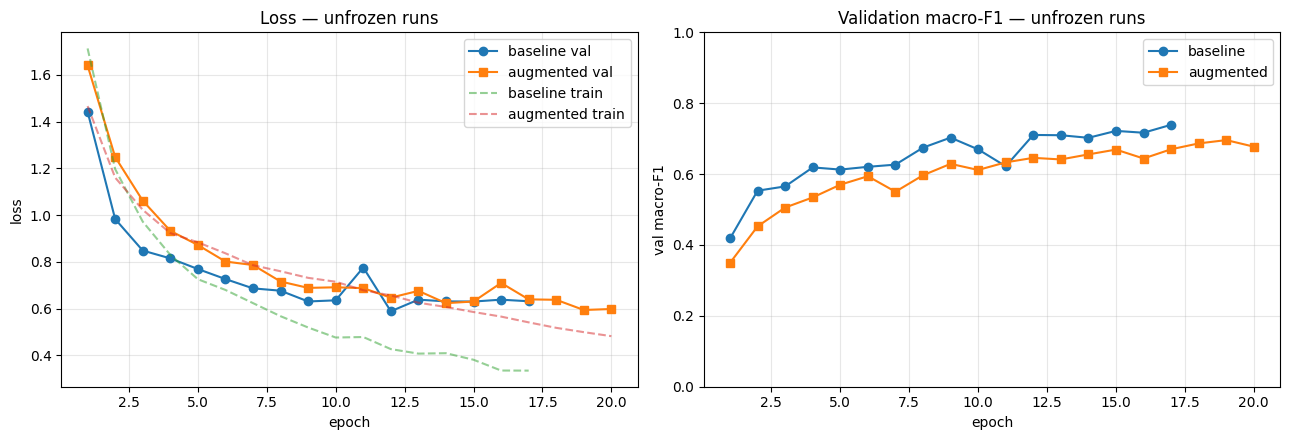

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist_baseline['epoch'],  hist_baseline['val_loss'],  marker='o', label='baseline val')
axes[0].plot(hist_augmented['epoch'], hist_augmented['val_loss'], marker='s', label='augmented val')
axes[0].plot(hist_baseline['epoch'],  hist_baseline['train_loss'], linestyle='--', alpha=0.5, label='baseline train')
axes[0].plot(hist_augmented['epoch'], hist_augmented['train_loss'], linestyle='--', alpha=0.5, label='augmented train')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss — unfrozen runs'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_baseline['epoch'],  hist_baseline['val_macro_f1'],  marker='o', label='baseline')
axes[1].plot(hist_augmented['epoch'], hist_augmented['val_macro_f1'], marker='s', label='augmented')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1')
axes[1].set_title('Validation macro-F1 — unfrozen runs'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
out = PLOTS_DIR / 'unfrozen_curves.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 13. Test-set evaluation

Load the best checkpoint of each run (picked on val macro-F1) and evaluate on the held-out test set. These are the honest report numbers.

In [14]:
def test_eval(ckpt_path, experiment_name):
    model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=False).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    ep = ckpt['epoch']
    vf = ckpt['val_macro_f1']
    print(f'{experiment_name}: loaded epoch {ep}  (val macro-F1 = {vf:.4f})')
    test_loss, test_acc, test_f1, test_bal, preds, labels = evaluate(
        model, test_loader, criterion, DEVICE,
    )
    print(f'  test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  '
          f'test_macro_f1={test_f1:.4f}  test_balanced_acc={test_bal:.4f}')
    return {
        'test_loss': test_loss, 'test_acc': test_acc,
        'test_macro_f1': test_f1, 'test_balanced_acc': test_bal,
        'preds': preds, 'labels': labels,
    }


test_baseline  = test_eval(ckpt_baseline,  'baseline_unfrozen')
test_augmented = test_eval(ckpt_augmented, 'augmented_unfrozen')

baseline_unfrozen: loaded epoch 17  (val macro-F1 = 0.7391)
  test_loss=0.6676  test_acc=0.8357  test_macro_f1=0.7382  test_balanced_acc=0.7915
augmented_unfrozen: loaded epoch 19  (val macro-F1 = 0.6959)
  test_loss=0.7116  test_acc=0.7878  test_macro_f1=0.6806  test_balanced_acc=0.7495


## 14. Per-class recall — baseline vs augmented (both unfrozen)

This is the core ablation table. It mirrors `results/logs/comparison_baseline_vs_augmented.csv` from Phase 10 but for the unfrozen runs.

In [15]:
rec_base = recall_score(test_baseline['labels'],  test_baseline['preds'],
                        labels=list(range(N_CLASSES)), average=None, zero_division=0)
rec_aug  = recall_score(test_augmented['labels'], test_augmented['preds'],
                        labels=list(range(N_CLASSES)), average=None, zero_division=0)

# Count synthetic samples added per class (from the AugmentedISICDataset)
synth_counts = {i: 0 for i in range(N_CLASSES)}
for cls_idx, source in SOURCES_PER_CLASS.items():
    # AugmentedISICDataset stores its synthetic items as extra rows; count by comparing to real
    pass
# Simpler: count from the manifest filtered by class
manifest_df = pd.read_csv(MANIFEST)
for cls_idx, source in SOURCES_PER_CLASS.items():
    if source == 'both':
        synth_counts[cls_idx] = int((manifest_df['label'] == cls_idx).sum())
    else:
        synth_counts[cls_idx] = int(((manifest_df['label'] == cls_idx) &
                                     (manifest_df['source'] == source)).sum())

rows = []
for i, name in enumerate(CLASS_NAMES):
    rows.append({
        'class': name,
        'baseline_unfrozen_recall':  rec_base[i],
        'augmented_unfrozen_recall': rec_aug[i],
        'delta':                     rec_aug[i] - rec_base[i],
        'synth_added':               synth_counts[i],
    })
rows.append({
    'class': 'OVERALL',
    'baseline_unfrozen_recall':  test_baseline['test_macro_f1'],
    'augmented_unfrozen_recall': test_augmented['test_macro_f1'],
    'delta':                     test_augmented['test_macro_f1'] - test_baseline['test_macro_f1'],
    'synth_added':               sum(synth_counts.values()),
})

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

out_csv = LOGS_DIR / 'comparison_unfrozen_baseline_vs_augmented.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'\\nsaved {out_csv}')

  class  baseline_unfrozen_recall  augmented_unfrozen_recall     delta  synth_added
    MEL                  0.676647                   0.688623  0.011976            0
     NV                  0.911531                   0.826044 -0.085487            0
    BCC                  0.818182                   0.792208 -0.025974          640
  AKIEC                  0.693878                   0.653061 -0.040816          771
    BKL                  0.557576                   0.684848  0.127273            0
     DF                  0.882353                   0.647059 -0.235294          920
   VASC                  1.000000                   0.954545 -0.045455          901
OVERALL                  0.738181                   0.680611 -0.057570         3232
\nsaved /home/mayarn/skin-cancer/skin-lesion/results/logs/comparison_unfrozen_baseline_vs_augmented.csv


## 15. Per-class recall bar chart

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/unfrozen_per_class_recall.png


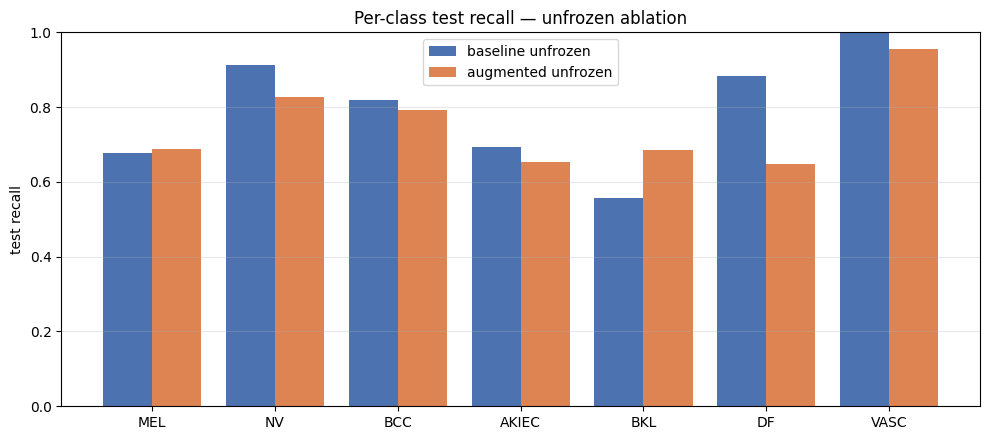

In [16]:
x = np.arange(N_CLASSES)
w = 0.4

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, rec_base, w, label='baseline unfrozen', color='#4C72B0')
ax.bar(x + w/2, rec_aug,  w, label='augmented unfrozen', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('test recall'); ax.set_ylim(0, 1)
ax.set_title('Per-class test recall — unfrozen ablation')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
out = PLOTS_DIR / 'unfrozen_per_class_recall.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 16. Confusion matrices side by side

Both row-normalised so the per-class story is easy to read regardless of class size.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/unfrozen_confusion.png


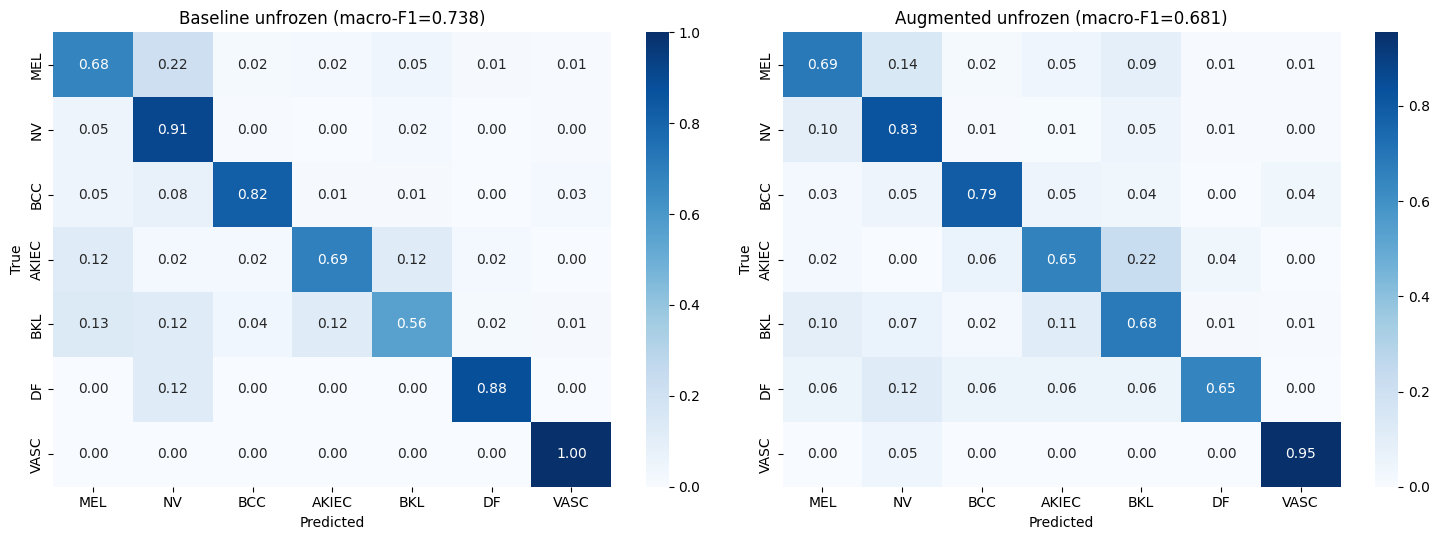

In [17]:
import seaborn as sns

cm_b = confusion_matrix(test_baseline['labels'],  test_baseline['preds'],  labels=list(range(N_CLASSES)))
cm_a = confusion_matrix(test_augmented['labels'], test_augmented['preds'], labels=list(range(N_CLASSES)))
cm_b_n = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)
cm_a_n = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm_b_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
b_f1 = test_baseline['test_macro_f1']
axes[0].set_title(f'Baseline unfrozen (macro-F1={b_f1:.3f})')

sns.heatmap(cm_a_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
a_f1 = test_augmented['test_macro_f1']
axes[1].set_title(f'Augmented unfrozen (macro-F1={a_f1:.3f})')

plt.tight_layout()
out = PLOTS_DIR / 'unfrozen_confusion.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 17. Frozen vs unfrozen — full ablation summary

The headline table for the report. Four numbers per class: frozen-baseline recall, frozen-augmented recall, unfrozen-baseline recall, unfrozen-augmented recall. This is what tells us whether unfreezing helps, whether augmentation helps, and whether the two stack.

In [18]:
frozen_csv = LOGS_DIR / 'comparison_baseline_vs_augmented.csv'

if frozen_csv.exists():
    frozen = pd.read_csv(frozen_csv)
    # frozen columns: class, baseline_recall, augmented_recall, delta, synth_added
    frozen_small = frozen[['class', 'baseline_recall', 'augmented_recall']].rename(columns={
        'baseline_recall':  'baseline_frozen',
        'augmented_recall': 'augmented_frozen',
    })

    unfrozen_small = comparison_df[['class', 'baseline_unfrozen_recall', 'augmented_unfrozen_recall']].rename(columns={
        'baseline_unfrozen_recall':  'baseline_unfrozen',
        'augmented_unfrozen_recall': 'augmented_unfrozen',
    })

    full = frozen_small.merge(unfrozen_small, on='class', how='outer')
    full['unfreeze_gain_baseline']  = full['baseline_unfrozen']  - full['baseline_frozen']
    full['unfreeze_gain_augmented'] = full['augmented_unfrozen'] - full['augmented_frozen']
    full['aug_gain_frozen']         = full['augmented_frozen']   - full['baseline_frozen']
    full['aug_gain_unfrozen']       = full['augmented_unfrozen'] - full['baseline_unfrozen']

    cols_show = ['class',
                 'baseline_frozen', 'augmented_frozen',
                 'baseline_unfrozen', 'augmented_unfrozen',
                 'unfreeze_gain_baseline', 'unfreeze_gain_augmented',
                 'aug_gain_frozen', 'aug_gain_unfrozen']

    print(full[cols_show].to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    out = LOGS_DIR / 'comparison_frozen_vs_unfrozen.csv'
    full.to_csv(out, index=False)
    print(f'\\nsaved {out}')
else:
    print('Frozen comparison CSV not found — skipping the cross-comparison table.')
    print(f'(expected at {frozen_csv})')

  class  baseline_frozen  augmented_frozen  baseline_unfrozen  augmented_unfrozen  unfreeze_gain_baseline  unfreeze_gain_augmented  aug_gain_frozen  aug_gain_unfrozen
  AKIEC            0.551             0.449              0.694               0.653                   0.143                    0.204           -0.102             -0.041
    BCC            0.519             0.519              0.818               0.792                   0.299                    0.273            0.000             -0.026
    BKL            0.430             0.558              0.558               0.685                   0.127                    0.127            0.127              0.127
     DF            0.353             0.471              0.882               0.647                   0.529                    0.176            0.118             -0.235
    MEL            0.467             0.557              0.677               0.689                   0.210                    0.132            0.090              0.01

## 18. Results summary

After Mayar runs this notebook, fill in the actual numbers below and these three questions:

1. Did unfreezing lift the baseline overall macro-F1 above the frozen baseline (0.550)?
2. Did unfreezing lift the augmented model above the frozen augmented (0.603)?
3. Did the AKIEC regression seen in the frozen augmented run (−0.10) survive the unfreeze, or was it a frozen-backbone artifact?

The three numbers to copy in from the CSVs above:

- Baseline unfrozen macro-F1: `___`
- Augmented unfrozen macro-F1: `___`
- AKIEC delta (augmented unfrozen − baseline unfrozen): `___`

If both runs lifted **and** the AKIEC regression disappeared, the report's main result becomes "augmentation helps, especially with full fine-tuning" and the unfrozen pair becomes the primary result with the frozen pair as a cheaper-baseline ablation. If the unfrozen baseline already beats the frozen augmented number, the project should be re-framed around full fine-tuning as the main pipeline and augmentation as the secondary lift.